In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configure plot styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Path to dataset (relative to notebooks directory)
data_path = Path("../data/Telco-Customer-Churn.csv")

# 1. Download/place the file in data/ and load it
df = pd.read_csv(data_path)
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# 2. Check shape, missing values, and data types
print("--- DATASET SHAPE ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- DATA TYPES & NON-NULL COUNTS ---")
print(df.info())

print("\n--- EXPLICIT NULL VALUES ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

--- DATASET SHAPE ---
Rows: 7043, Columns: 21

--- DATA TYPES & NON-NULL COUNTS ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract        

In [4]:
# 3. Fix TotalCharges column (convert blank strings " " to NaN, then fill with 0)
print(
    f"Blank space count in TotalCharges: {(df['TotalCharges'] == ' ').sum()}"
)

# Coerce non-numeric string values to NaN and convert to float
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing TotalCharges with 0 (since missing entries correspond to tenure = 0)
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print(
    f"Fixed TotalCharges dtype: {df['TotalCharges'].dtype}, Null count: {df['TotalCharges'].isnull().sum()}"
)

Blank space count in TotalCharges: 11
Fixed TotalCharges dtype: float64, Null count: 0


/tmp/ipykernel_20031/1966062682.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_20031/1966062682.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_20031/1966062682.py:41: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(


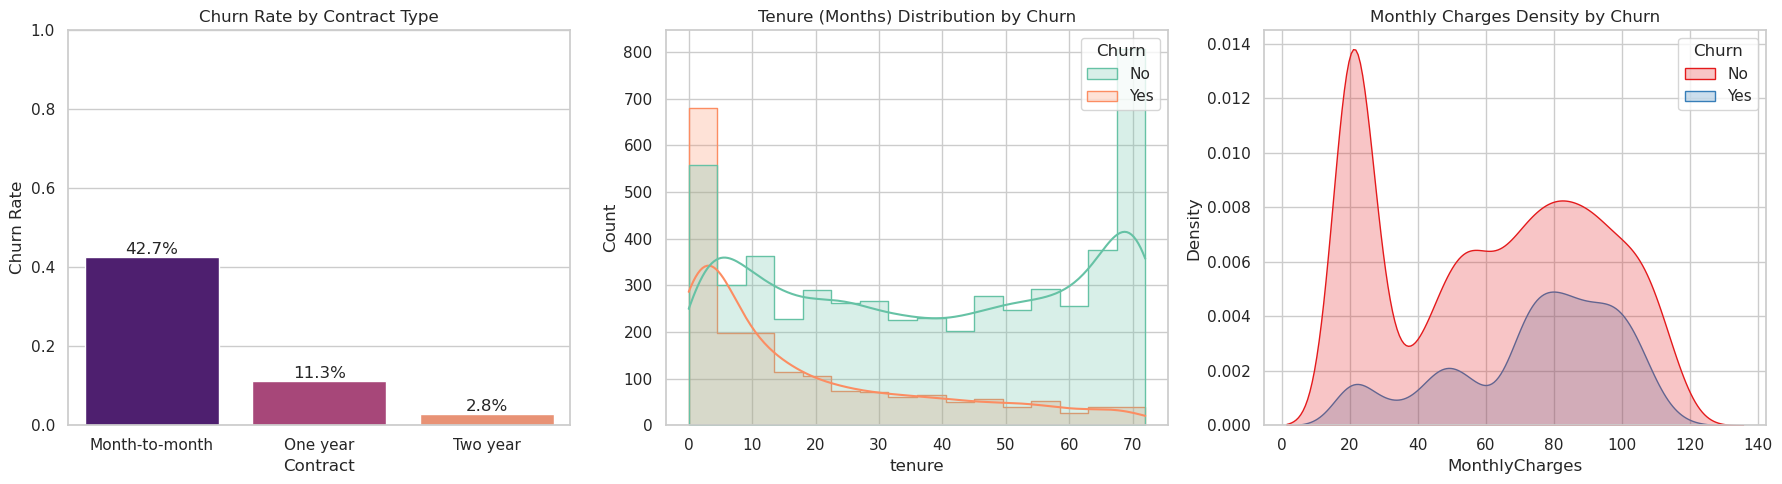

In [5]:
# 4. Plot churn rate by contract type, tenure, and monthly charges

# Normalize Churn column for calculations (Yes=1, No=0)
df["Churn_Numeric"] = df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Churn Rate by Contract Type
sns.barplot(
    data=df,
    x="Contract",
    y="Churn_Numeric",
    ax=axes[0],
    palette="magma",
    ci=None,
)
axes[0].set_title("Churn Rate by Contract Type")
axes[0].set_ylabel("Churn Rate")
axes[0].set_ylim(0, 1)
for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
    )

# Plot 2: Tenure Distribution by Churn Status
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    kde=True,
    ax=axes[1],
    palette="Set2",
    element="step",
)
axes[1].set_title("Tenure (Months) Distribution by Churn")

# Plot 3: Monthly Charges Distribution by Churn Status
sns.kdeplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    shade=True,
    ax=axes[2],
    palette="Set1",
)
axes[2].set_title("Monthly Charges Density by Churn")

plt.tight_layout()
plt.show()

# CORE FINDINGS

Contract Type Impact: Customers on Month-to-month contracts exhibit the highest churn rate (~42%), whereas customers on One-year (~11%) and Two-year (~3%) contracts show significantly higher retention.

Tenure Sensitivity: Churn is heavily concentrated in early customer lifecycles. New customers in their first 1–12 months show a major churn peak, whereas churn drops off sharply as tenure exceeds 24 months.

Price Sensitivity: Higher MonthlyCharges correlate directly with increased customer churn. The churn density peaks significantly for customers billed between $70 and $100+ per month, whereas low-tier bills ($20–$30) have higher loyalty.